# Objective
To try different optimisers on the dataset and see the perfomrance on the basis of how fast and accurate they converge at the end

In [5]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam, SGD, RMSprop, Adagrad
from src.utils import plot_history, print_accuracy, plot_value_per_epoch
from src.train_ann_model import train_model
import matplotlib.pyplot as plt


In [7]:
df_train = pd.read_csv('../data/fashion-mnist_train.csv')
df_test = pd.read_csv('../data/fashion-mnist_test.csv')

In [8]:
scaler = MinMaxScaler()
labels = df_train.pop('label')
inputs = scaler.fit_transform(df_train.values)

In [9]:
y_test = df_test.pop('label')
x_test = scaler.fit_transform(df_test)

## Optimisers shootout on FashionMNIST dataset

In [10]:
model_with_only_sgd, model_history_with_only_sgd, wall_clock_times_with_only_sgd = train_model(inputs, labels, SGD(), False, epochs=20, batch_size=32)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

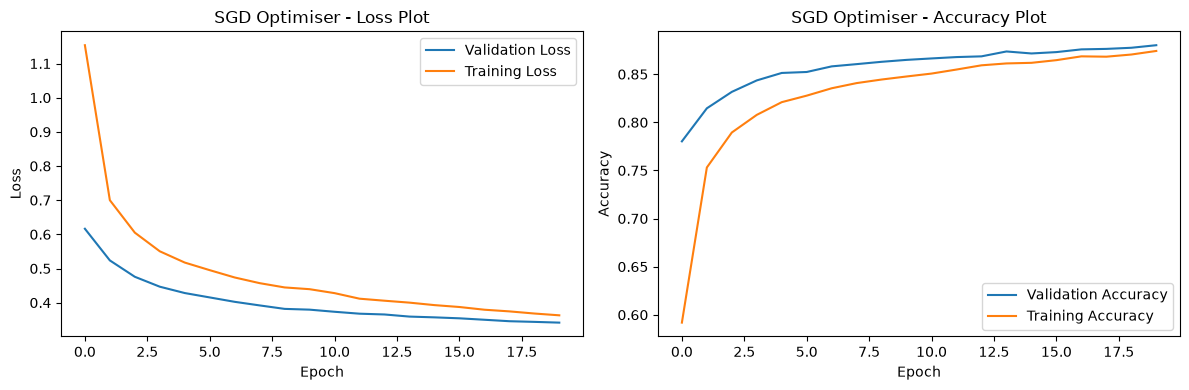

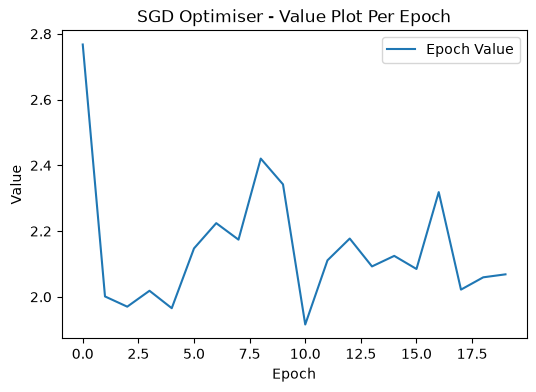

Test Accuracy: 0.8791
Avg wall clock time per epoch with SGD optimiser:  2.150292932987213


In [11]:
plot_history(model_history_with_only_sgd, "SGD Optimiser")
plot_value_per_epoch(wall_clock_times_with_only_sgd, "SGD Optimiser")
print_accuracy(model_with_only_sgd, x_test, y_test)
print("Avg wall clock time per epoch with SGD optimiser: ", np.mean(wall_clock_times_with_only_sgd))

In [12]:
model_with_sgd_with_momentum, model_history_with_sgd_with_momentum, wall_clock_times_with_sgd_with_momentum = train_model(inputs, labels, SGD(momentum=0.9), False, epochs=20, batch_size=32)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

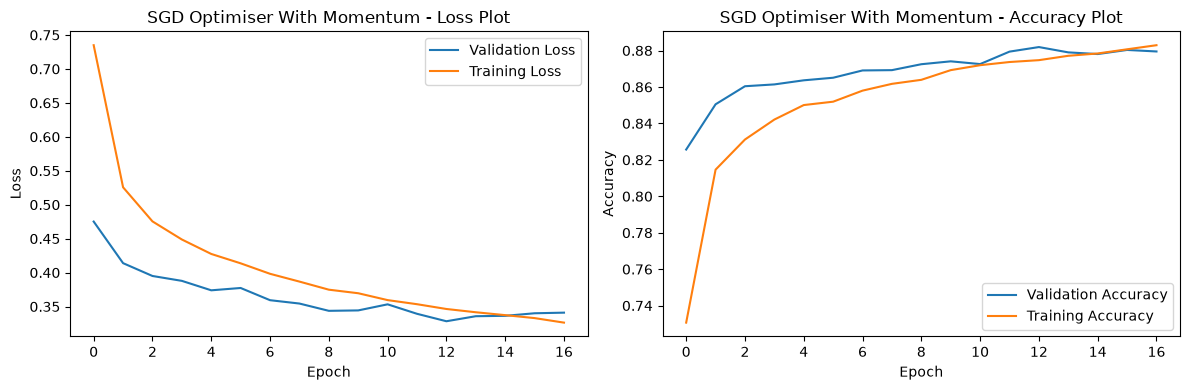

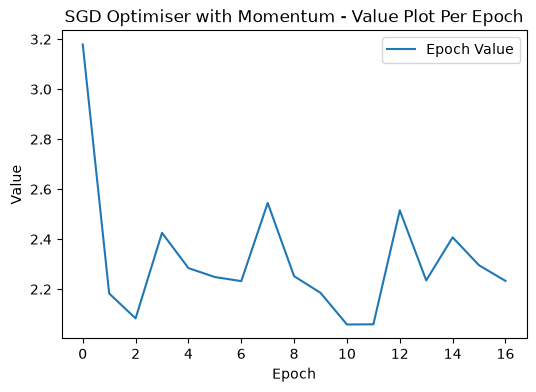

Test Accuracy: 0.8810
Avg wall clock time per epoch with SGD optimiser with momentum:  2.3189588294309726


In [13]:
plot_history(model_history_with_sgd_with_momentum, "SGD Optimiser With Momentum")
plot_value_per_epoch(wall_clock_times_with_sgd_with_momentum, "SGD Optimiser with Momentum")
print_accuracy(model_with_sgd_with_momentum, x_test, y_test)
print("Avg wall clock time per epoch with SGD optimiser with momentum: ", np.mean(wall_clock_times_with_sgd_with_momentum))

In [14]:
model_with_sgd_with_nag, model_history_with_sgd_with_nag, wall_clock_times_with_sgd_with_nag = train_model(inputs, labels, SGD(momentum=0.9, nesterov=True), False, epochs=20, batch_size=32)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

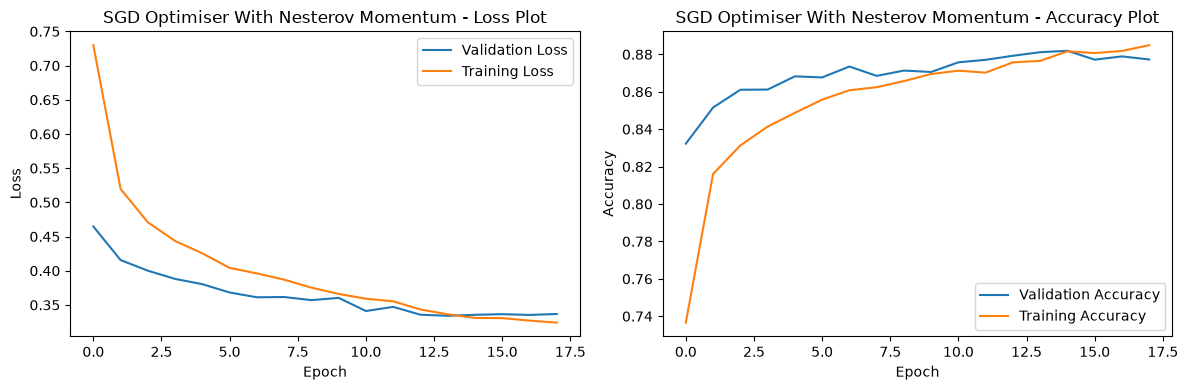

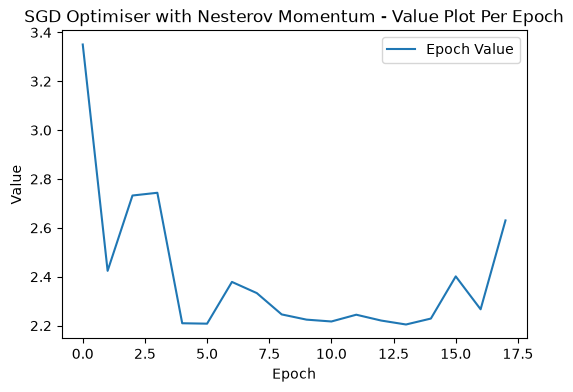

Test Accuracy: 0.8830
Avg wall clock time per epoch with SGD optimiser with Nesterov momentum:  2.403658482763502


In [15]:
plot_history(model_history_with_sgd_with_nag, "SGD Optimiser With Nesterov Momentum")
plot_value_per_epoch(wall_clock_times_with_sgd_with_nag, "SGD Optimiser with Nesterov Momentum")
print_accuracy(model_with_sgd_with_nag, x_test, y_test)
print("Avg wall clock time per epoch with SGD optimiser with Nesterov momentum: ", np.mean(wall_clock_times_with_sgd_with_nag))

In [16]:
model_with_only_adam, model_history_with_only_adam, wall_clock_times_with_only_adam = train_model(inputs, labels, Adam(), False, epochs=20, batch_size=32)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

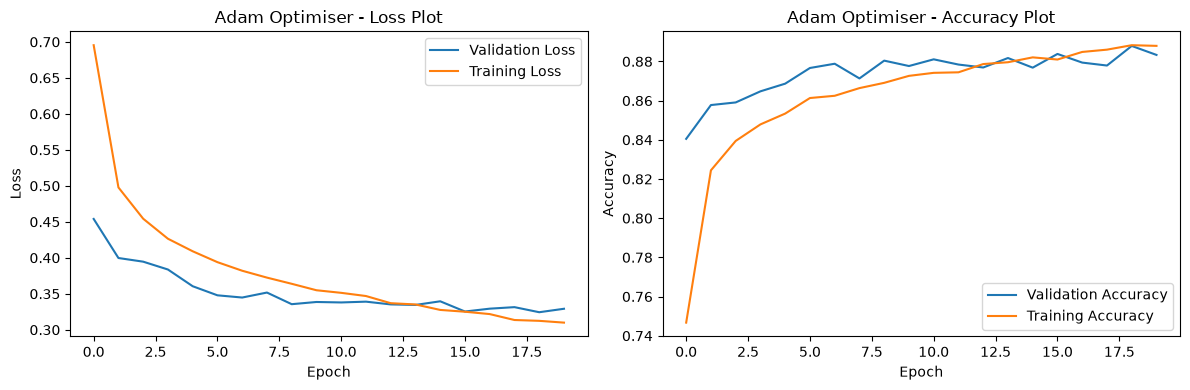

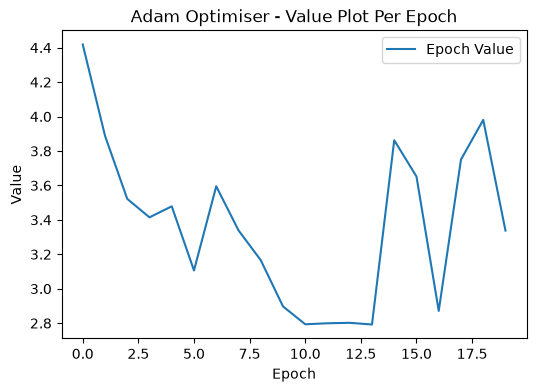

Test Accuracy: 0.8850
Avg wall clock time per epoch with Adam optimiser:  3.3733421325683595


In [17]:
plot_history(model_history_with_only_adam, "Adam Optimiser")
plot_value_per_epoch(wall_clock_times_with_only_adam, "Adam Optimiser")
print_accuracy(model_with_only_adam, x_test, y_test)
print("Avg wall clock time per epoch with Adam optimiser: ", np.mean(wall_clock_times_with_only_adam))

In [18]:
model_with_Adagrad, model_history_with_Adagrad, wall_clock_times_with_Adagrad = train_model(inputs, labels, Adagrad(), False, epochs=20, batch_size=32)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

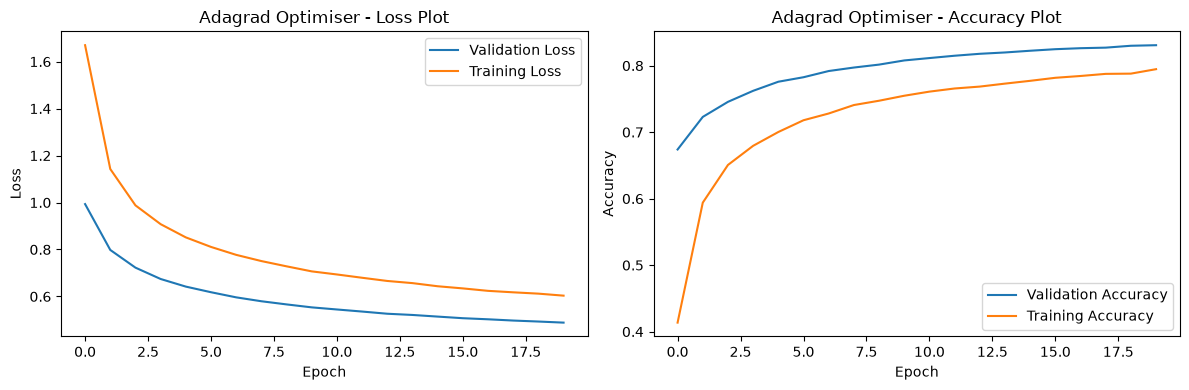

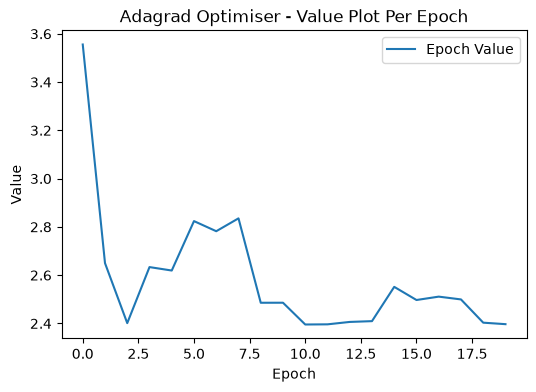

Test Accuracy: 0.8269
Avg wall clock time per epoch with Adagrad optimiser:  2.587020421028137


In [19]:
plot_history(model_history_with_Adagrad, "Adagrad Optimiser")
plot_value_per_epoch(wall_clock_times_with_Adagrad, "Adagrad Optimiser")
print_accuracy(model_with_Adagrad, x_test, y_test)
print("Avg wall clock time per epoch with Adagrad optimiser: ", np.mean(wall_clock_times_with_Adagrad))

In [20]:
model_with_rmsprop, model_history_with_rmsprop, wall_clock_times_with_rmsprop = train_model(inputs, labels, RMSprop(), False, epochs=20, batch_size=32)

Run script with 'sudo' on Mac/Linux to force higher CPU priority.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

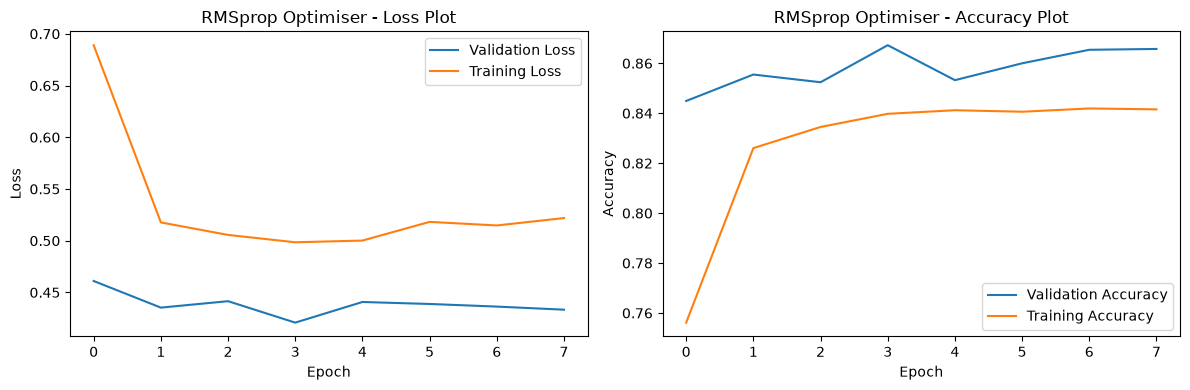

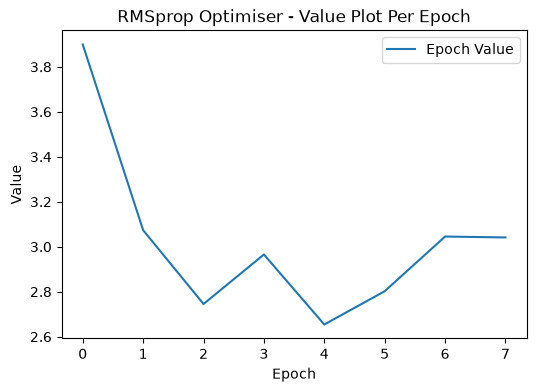

Test Accuracy: 0.8685
Avg wall clock time per epoch with RMSprop optimiser:  3.0283960700035095


In [21]:
plot_history(model_history_with_rmsprop, "RMSprop Optimiser")
plot_value_per_epoch(wall_clock_times_with_rmsprop, "RMSprop Optimiser")
print_accuracy(model_with_rmsprop, x_test, y_test)
print("Avg wall clock time per epoch with RMSprop optimiser: ", np.mean(wall_clock_times_with_rmsprop))

## Analysis of Optimizer Performance and Training Dynamics

This document summarizes the observations made from comparing various optimization algorithms during the training of an Artificial Neural Network (tested on datasets like Fashion MNIST). The analysis is based on loss and accuracy plots generated over multiple epochs.

### General Observations Across Models

Validation vs. Training Metrics: In almost all the initial plots, Validation Loss started lower than Training Loss, and Validation Accuracy started higher than Training Accuracy. This is a classic theoretical signature of using Dropout or strong regularization. Because Dropout artificially disables neurons during training (lowering performance) but is turned off during validation, the model performs at its full capacity on the validation set. Time per epoch is a culmination of many things as I trained everything on my local computer. So its slightly diff from the actual theory

### Standard Optimizers vs. Accelerated Optimizers

Stochastic Gradient Descent (Vanilla SGD)

Behavior: The standard SGD plots showed a very steady, almost sluggish decline in loss.

Observation: As the epochs progressed and the model approached flat regions of the loss landscape (where gradients are small), the descent slowed down significantly. In the custom implementation test, SGD without momentum ($\beta = 0$) only reached a training loss of ~0.25 after 200 epochs, spending the last 150 epochs crawling downwards.

SGD with Momentum & Nesterov Momentum

Behavior: Adding momentum fundamentally changed the convergence trajectory.

Observation: The plots showed a much steeper initial drop in loss and a sharper initial climb in accuracy during the first few epochs compared to standard SGD. Momentum acts like a ball rolling down a hill, building velocity and accelerating through flat regions.

Result: The momentum optimizers achieved a lower final loss (~0.32) and higher accuracy (~0.88) in fewer epochs (triggering early stopping around 16 epochs, compared to the 20+ epochs needed for standard SGD). Minor oscillations/bumps were observed in the validation curve, which is characteristic of the momentum "overshooting" slightly before correcting itself.

### Adaptive Learning Rate Optimizers

Adaptive optimizers scale the learning rate for each parameter individually based on past gradients.

Adagrad

Behavior: Adagrad produced a very smooth, asymptotic curve.

Observation: Because Adagrad accumulates the squares of all past gradients, its effective learning rate monotonically decreases over time. This resulted in a slower, smoother convergence curve compared to other adaptive methods, exactly matching theoretical expectations.

RMSprop and Adam

Behavior: Both optimizers demonstrated extremely rapid initial convergence.

Observation: The loss dropped precipitously in the earliest epochs. RMSprop converged so quickly that it appeared to trigger early stopping by epoch 7. Adam, which combines the benefits of both Momentum and RMSprop, showed strong, stable convergence, making it highly efficient.